In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image


img_path = "../data/cat_dog/test/cats/cat.4.jpg"



<class 'numpy.ndarray'>


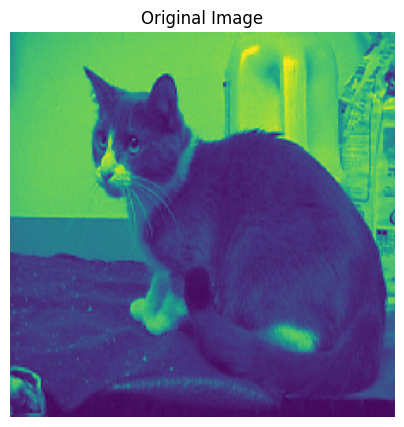

In [ ]:

# Load image
img = image.load_img(img_path, target_size=(224, 224), color_mode="grayscale")

# Convert image to numpy array
img_array = image.img_to_array(img)

print(type(img_array))
plt.figure(figsize=(14, 5))
plt.imshow(img_array.astype("uint8"), cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

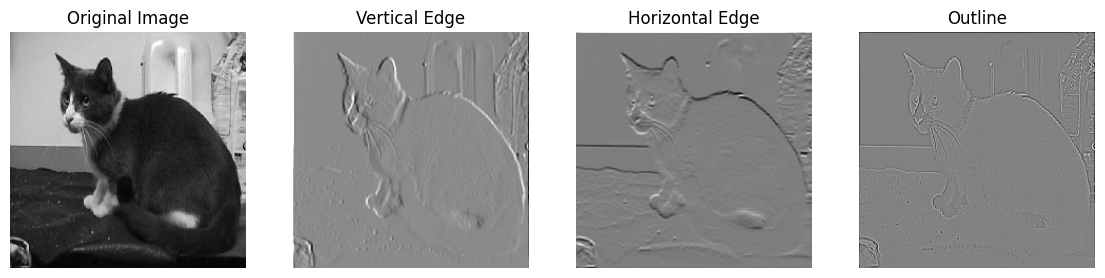

In [15]:

# Normalize pixel values
img_array = img_array / 255

# Conv2D input shape should be: batch, height, width, channel
input_img = np.expand_dims(img_array, axis=0)

# Create Conv2D layer with 3 filters
conv_layer = tf.keras.layers.Conv2D(
    filters=3,
    kernel_size=(3, 3),
    padding="same",
    use_bias=False
)

# Build layer
conv_layer(input_img)

# Define filters manually
vertical_edge = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

horizontal_edge = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

outline = np.array([
    [ 0,  1,  0],
    [ 1, -4,  1],
    [ 0,  1,  0]
], dtype=np.float32)

# Conv2D kernel shape:
# height, width, input_channel, number_of_filters
kernel = np.zeros((3, 3, 1, 3), dtype=np.float32)

kernel[:, :, 0, 0] = vertical_edge
kernel[:, :, 0, 1] = horizontal_edge
kernel[:, :, 0, 2] = outline

# Set filters into Conv2D layer
conv_layer.set_weights([kernel])

# Apply Conv2D
output = conv_layer(input_img)

# Convert tensor to numpy
output = output.numpy()[0]

# Plot everything
plt.figure(figsize=(14, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_array.squeeze(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(output[:, :, 0], cmap="gray")
plt.title("Vertical Edge")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(output[:, :, 1], cmap="gray")
plt.title("Horizontal Edge")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(output[:, :, 2], cmap="gray")
plt.title("Outline")
plt.axis("off")

plt.show()